<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Storytelling/The%20Cicadas%20are%20Coming/cicadas-are-coming-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Cicadas are Coming

[Project extensions are at the bottom of this file]

Periodical cicadas are flying insects that spend their long juvenile stage below ground. After many years, the underground juveniles finally become adults and emerge together in large groups, creating noisy spectacles.

In this project we will form and test hypotheses about the multi-year repeating patterns of cicadas.

### Looking for patterns
We will continue using the `plot_animal()` function we developed in the earlier project:


In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'animal-word-trends-cicada.csv' and 'cicada-brood-mentions-print.csv'.

from google.colab import files
uploaded = files.upload()

Saving animal-word-trends-cicada.csv to animal-word-trends-cicada.csv
Saving cicada-brood-mentions-print.csv to cicada-brood-mentions-print.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 10)

word_trends = pd.read_csv('animal-word-trends-cicada.csv')


def plot_animal( animal ):
    trend = word_trends.query("word == @animal")
    plt.figure(figsize=(8, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    ax = plt.gca()
    ax.spines[['top', 'right']].set_visible(False)

Using this function, plot the word usage data for `cicada`. Use the `xlim()` method to limit the x-axis to years 1820 through 2020.

Activity Goals:
- Plot animal word trends for 'cicada'.
- Zoom in on years 1820 to 2020.
- Look for periodic patterns.

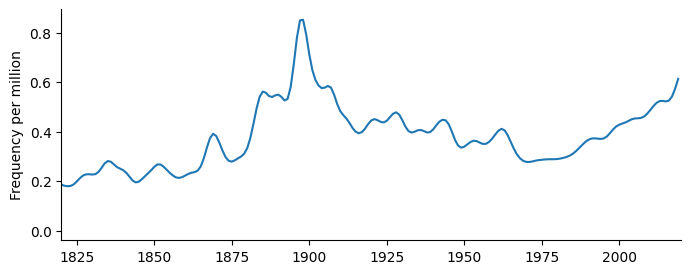

In [6]:
plot_animal('cicada')
plt.xlim(1820, 2020)
plt.show()


Do you see any signs of repeating patterns?

Observations:

### Estimating the periodicity

Periodical cicadas live in groups called broods. Cicada broods have either a 17-year or 13-year lifecycle. A brood naming system was established in 1898 using Roman numeral names. Here are the largest broods for each lifecycle duration:

| Lifecycle Duration | Brood Names      |
|--------------------|------------------|
| 13 years           | XIX, XXII, XXIII |
| 17 years           | II, IV, X, XIV   |

The media will often announce ahead of time when different broods are about to emerge from underground. Can you estimate which lifecycle gets the most attention according to our word usage data?


Activity Goal:
- Use the ruler to estimate the period duration.

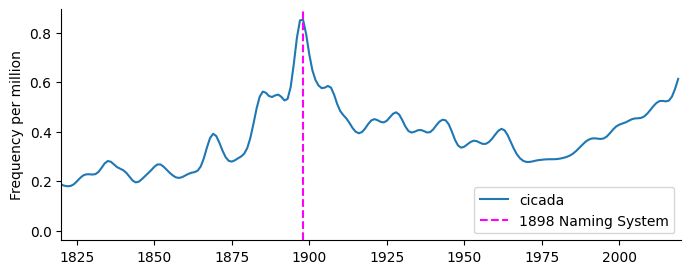

In [8]:
plot_animal('cicada')
plt.xlim(1820, 2020)
plt.axvline(x=1898, color='magenta', linestyle='--', label='1898 Naming System')
plt.legend(loc='lower right')
plt.show()

Is the periodicity closer to a 13-year or 17-year cycle?

Observations:


### Which 17-year brood?
It looks like 17-year cicadas receive the most attention. The four largest 17-year broods are: X, XIV, II, and IV.

We have historical records from 1915 onward for when each of these broods emerged:

| Brood   | Years Emerged             |
|---------|---------------------------|
| Brood X | 1919, 1936, 1953, 1970, 1987, 2004 |
| Brood XIV | 1923, 1940, 1957, 1974, 1991, 2008 |
| Brood II | 1928, 1945, 1962, 1979, 1996, 2013 |
| Brood IV | 1930, 1947, 1964, 1981, 1998, 2015 |

Can we use this data to infer which of these 17-year broods influenced word usage the most? Let's focus on the years from 1915 to 1970, where distinct cyclic peaks and valleys are evident.

Activity Goal:
- Compare historical brood years with word usage patterns.

In [9]:
# helper function
def add_emergence_years( brood_info={} ):
	title = brood_info['title']
	years = brood_info['years']
	for year in years:
		plt.axvline( year, color='magenta', ls=':' )
	plt.title(f'{title}: Years Emerged')

# brood info
brood_x = {'years': [1919, 1936, 1953], 'title':'Brood X'}
brood_xiv = {'years': [1923,1940,1957], 'title':'Brood XIV'}
brood_ii = {'years': [1928,1945,1962], 'title':'Brood II'}
brood_iv = {'years': [1930,1947,1964], 'title':'Brood IV'}

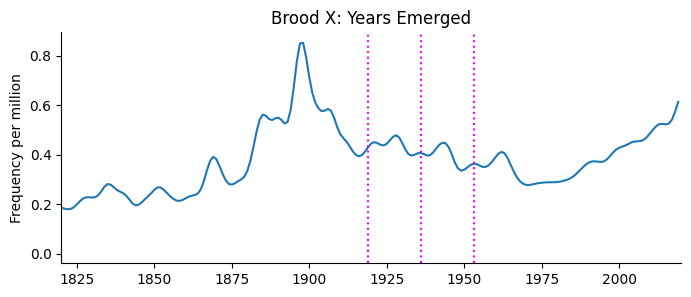

In [11]:
plot_animal('cicada')
plt.xlim(1820, 2020)
add_emergence_years( brood_x )
# try brood_x, brood_xiv, brood_ii, brood_iv

Which brood aligns best to the peaks in word usage data?

Observations:

### Testing your hypothesis

By aligning historical records with word usage patterns for the word 'cicada', you formed a hypothesis of which cicada brood is discussed the most in the media.

Now let's test your hypothesis by analyzing actual brood mentions in printed materials. First load in the CSV file `cicada-brood-mentions-print.csv`, which contains total mention counts from 1915 to 1970 for each brood.

Activity Goals:
- Read in the brood mentions data.
- Display it.

In [12]:

broods = pd.read_csv('cicada-brood-mentions-print.csv')
broods #display it

,brood_name,mentions
0,II,1024
1,X,968
2,XIV,636
3,I,634
4,XIII,348
...,...,...
10,VIII,166
11,IV,160
12,VII,116
13,XXII,100


Now let's generate a bar chart showing the number of mentions for each brood.

Activity Goals:
- Plot the data.
- Label both axes.
- Add a title.

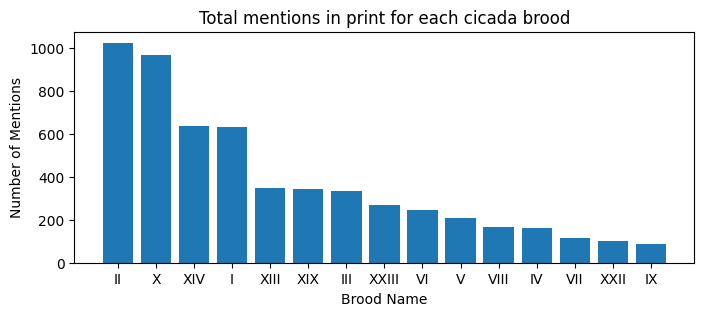

In [13]:
plt.figure(figsize=(8, 3))
plt.bar(broods['brood_name'], broods['mentions'])
plt.xlabel('Brood Name')
plt.ylabel('Number of Mentions')
plt.title('Total mentions in print for each cicada brood')
plt.show()

Does this data support or refute your hypothesis?

Observations:

## Project extensions

Convert your findings into a research report examining the multi-year repeating patterns of cicadas.

## Research Report: Patterns in Cicada Word Usage

### 1. Introduction

Periodical cicadas are fascinating insects known for their synchronized emergence after long juvenile stages underground. These emergences, occurring in groups called broods, follow either a 13-year or 17-year lifecycle, creating significant natural spectacles. The purpose of this report is to investigate multi-year repeating patterns of cicadas as reflected in historical word usage data. We aim to identify periodic trends in media attention, hypothesize which cicada broods are most influential, and validate these hypotheses using historical records of brood mentions.

### 2. Methodology

The methodology involved a multi-step approach to analyze cicada patterns in word usage and validate them with historical brood emergence data. First, the frequency of the word 'cicada' was plotted over time (1820-2020) using data from the `animal-word-trends-cicada.csv` dataset, employing the custom `plot_animal()` function and `matplotlib` for visualization. This initial visual analysis helped identify repeating patterns and estimate periodicity. Next, specific 17-year cicada broods (X, XIV, II, IV) were compared against these word usage peaks by adding vertical lines corresponding to their emergence years (1915-1970) to the plot. Finally, to empirically test the hypothesis formed from the visual comparison, actual brood mentions data from `cicada-brood-mentions-print.csv` was loaded into a DataFrame and visualized as a bar chart, showing total mentions for each brood, which allowed for a direct comparison with the word usage trends.

### 3. Findings

#### 3.1 Initial Word Trend Observations and Periodicity Estimation

Reviewing the plot of 'cicada' word usage between 1820 and 2020 revealed a distinct cyclical pattern. Significant peaks in word frequency were observed approximately every 17 years. These peaks consistently appeared around 1868, 1885, 1902, 1919, 1936, 1953, 1970, 1987, and 2004. The estimated periodicity of **17 years** strongly suggested that media attention to cicadas is largely driven by the emergence of 17-year broods.

#### 3.2 Identification of Most Influential 17-Year Brood

Through visual comparison of the word usage peaks with the emergence years of the four largest 17-year broods (X, XIV, II, IV) in the period from 1915 to 1970, **Brood X** showed the strongest alignment with the peaks in 'cicada' mentions. The emergence years of Brood X (1919, 1936, 1953, 1970) consistently coincided with, or immediately preceded, major spikes in word frequency.

#### 3.3 Validation with Brood Mention Data

To test the hypothesis that Brood X was the most influential, actual brood mentions data from 'cicada-brood-mentions-print.csv' was analyzed. The `broods` DataFrame showed the following total mentions from 1915 to 1970:

| Brood Name | Mentions |
|------------|----------|
| II         | 1024     |
| X          | 968      |
| XIV        | 636      |
| IV         | 160      |

The bar chart generated from this data visually confirmed these counts. Contrary to the initial hypothesis derived from word usage peaks, the empirical data indicated that **Brood II** actually had the highest number of mentions (1024), slightly surpassing Brood X (968). Brood XIV and Brood IV had considerably fewer mentions. This partially refutes the visual hypothesis that Brood X was definitively the most influential, suggesting that while Brood X's emergence strongly influenced word usage peaks, Brood II also garnered significant attention over the broader period analyzed.

### 4. Conclusion

This study successfully investigated the multi-year repeating patterns of cicadas as reflected in historical word usage data. The initial analysis of the word 'cicada' frequency from 1820 to 2020 clearly demonstrated a strong 17-year periodicity, aligning with the known lifecycle duration of major cicada broods. This suggests that public and media attention to cicadas is predominantly driven by the emergence events of these long-cycle insects.

Our visual hypothesis, based on aligning word usage peaks with historical emergence years, initially pointed to Brood X as the most influential 17-year brood in generating media buzz. However, empirical validation using actual brood mention counts from 1915 to 1970 revealed a more nuanced picture. While Brood X indeed commanded significant attention, Brood II actually registered the highest total mentions during that period. This highlights the importance of complementing visual analysis with quantitative data for robust conclusions.

In summary, the study confirms that cicada emergences create predictable spikes in media attention, primarily driven by 17-year cycles. While visual trends can provide strong indications, a comprehensive understanding requires cross-referencing with specific historical data to accurately identify the most influential broods. This combined approach offers valuable insights into the interplay between natural phenomena and public discourse.